In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.types import IntegerType, DoubleType, StringType
spark = SparkSession.builder.appName("BTC-Feature-Analysis").getOrCreate()
df_spark = spark.read.parquet("../data/silver/btc_features/")
df_spark.show(5)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/01/21 14:31:09 WARN Utils: Your hostname, ELBAHIA, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/01/21 14:31:09 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/01/21 14:31:12 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


+-------------------+--------+--------+--------+--------+--------+--------------------+------------------+----------------+---------------------+----------------------+------+---------------+----------+--------------------+-----------------+-----------------+-------------------+
|          open_time|    open|    high|     low|   close|  volume|          close_time|quote_asset_volume|number_of_trades|taker_buy_base_volume|taker_buy_quote_volume|ignore|close_t_plus_10|close_prev|           return_1m|             ma_5|            ma_10|        taker_ratio|
+-------------------+--------+--------+--------+--------+--------+--------------------+------------------+----------------+---------------------+----------------------+------+---------------+----------+--------------------+-----------------+-----------------+-------------------+
|2026-01-20 05:27:00|91658.54|91747.05|91658.54|91713.95| 17.8326|2026-01-20 05:27:...|   1635452.6459378|            3905|              9.31005|        853705.

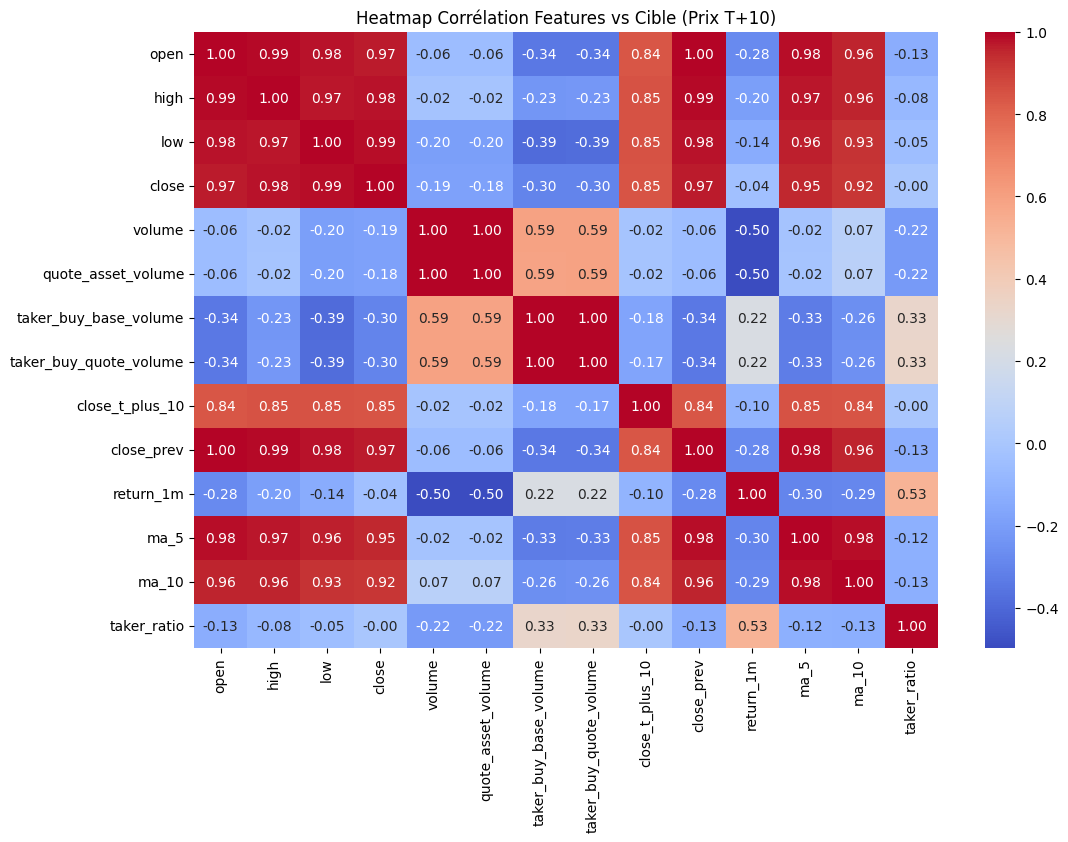

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1️⃣ Choisir les colonnes numériques à analyser (features + target)
corr_features =  [field.name for field in df_spark.schema.fields 
                if isinstance(field.dataType, (IntegerType, DoubleType))]

# 2️⃣ Échantillonner pour éviter d'utiliser trop de mémoire
pdf = df_spark.select(corr_features).dropna().sample(fraction=0.1, seed=42).toPandas()

# 3️⃣ Calculer la matrice de corrélation
corr_matrix = pdf.corr()

# 4️⃣ Heatmap avec seaborn
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Heatmap Corrélation Features vs Cible (Prix T+10)")
plt.show()



In [3]:
from pyspark.ml.feature import VectorAssembler

features_keep = [ "open","high","low","close","return_1m","ma_5","ma_10","volume","close_prev","number_of_trades"]

assembler = VectorAssembler(inputCols=features_keep, outputCol="features")

df_model = assembler.transform(df_spark).select("features", "close_t_plus_10")
train_data, test_data = df_model.randomSplit([0.8, 0.2], seed=42)

In [4]:
from pyspark.ml.regression import GBTRegressor

from pyspark.ml.evaluation import RegressionEvaluator

gbt = GBTRegressor(
    featuresCol="features",
    labelCol="close_t_plus_10",
    predictionCol="gbt_prediction",
    maxIter=100,    
    maxDepth=5,
    seed=42

)
gbt_model = gbt.fit(train_data)

gbt_preds = gbt_model.transform(test_data)


for metric in ["rmse", "mae"]:
   
    score = RegressionEvaluator(
        labelCol="close_t_plus_10",
        predictionCol="gbt_prediction",
        metricName=metric
    ).evaluate(gbt_preds)

    print(f"{metric.upper()} du GBT : {score}")

26/01/21 14:32:01 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


RMSE du GBT : 149.06165701367942
MAE du GBT : 110.10922061297923


In [10]:
from pyspark.ml.regression import RandomForestRegressor 
rf = RandomForestRegressor(
    featuresCol="features",
    labelCol="close_t_plus_10",
    predictionCol="rf_prediction",
    numTrees=50,
    maxDepth=7,
    seed=42
)

rf_model = rf.fit(train_data)
rf_preds = rf_model.transform(test_data)

for metric in ["rmse", "mae","r2"]:
    score = RegressionEvaluator(
        labelCol="close_t_plus_10",
        predictionCol="rf_prediction",
        metricName=metric
    ).evaluate(rf_preds)
    print(f"{metric.upper()} du Random Forest : {score}")

RMSE du Random Forest : 130.04745113638825
MAE du Random Forest : 97.45267354999147
R2 du Random Forest : 0.8299688082226759


In [11]:
from pyspark.ml.regression import LinearRegression



lr = LinearRegression( featuresCol="features", labelCol="close_t_plus_10",)
lr_model = lr.fit(train_data)

predictions = lr_model.transform(test_data)

for metric in ["rmse", "mae","r2"]:
    score = RegressionEvaluator(
        labelCol="close_t_plus_10",
        predictionCol="prediction",
        metricName=metric
    ).evaluate(predictions)
    print(f"{metric.upper()} du  Regression Linear : {score}")



26/01/21 14:41:19 WARN Instrumentation: [6af6e95a] regParam is zero, which might cause numerical instability and overfitting.


RMSE du  Regression Linear : 155.9203934688731
MAE du  Regression Linear : 114.520817822989
R2 du  Regression Linear : 0.7555833689371579


In [15]:
rf_model.save("models/pyspark_rf_model")